# Telco Customer Churn Prediction

**Author:** Fatima-Ezzahra ABOUTALEB  
**Course:** Machine Learning  


---



##  Setup & Imports

In [0]:
%pip install -r /Workspace/Users/fatimaezzahraaboutaleb5@gmail.com/telco-churn-ml-databricks/requirements.txt


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.tensorflow

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, 
                            classification_report, roc_curve)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✓ All libraries imported successfully!")
print(f"✓ MLflow version: {mlflow.__version__}")

✓ All libraries imported successfully!
✓ MLflow version: 3.9.0


##  1. Load Data

In [0]:
# Load dataset from DBFS or local path
# For Databricks, upload the CSV to DBFS first
# DATA_PATH = "/dbfs/FileStore/tables/WA_Fn_UseC__Telco_Customer_Churn.csv"

# Alternative paths:
# DATA_PATH = "dbfs:/FileStore/tables/WA_Fn_UseC__Telco_Customer_Churn.csv"
DATA_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"  # For local

df = pd.read_csv(DATA_PATH)

print("="*80)
print("DATASET LOADED")
print("="*80)
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print("\nFirst 5 rows:")
display(df.head())

DATASET LOADED
Shape: (7043, 21)
Rows: 7,043 | Columns: 21

First 5 rows:


customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes


### 📈 Dataset Overview

In [0]:
# Basic information
print("="*80)
print("DATASET INFORMATION")
print("="*80)
print(df.info())

print("\n" + "="*80)
print("MISSING VALUES")
print("="*80)
print(df.isnull().sum())

print("\n" + "="*80)
print("CHURN DISTRIBUTION")
print("="*80)
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {(df['Churn'] == 'Yes').mean() * 100:.2f}%")

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

## 2. Data Cleaning & Preprocessing

In [0]:
# Create a copy
df_clean = df.copy()

# 1. Remove customerID
if 'customerID' in df_clean.columns:
    df_clean.drop('customerID', axis=1, inplace=True)
    print("✓ Removed customerID column")

# 2. Convert TotalCharges to numeric
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print(f"✓ Converted TotalCharges to numeric")

# 3. Handle missing values
missing_count = df_clean['TotalCharges'].isnull().sum()
if missing_count > 0:
    print(f"⚠ Found {missing_count} missing values in TotalCharges")
    df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)
    print(f"✓ Filled missing values with median")

# 4. Identify feature types
numerical_features = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Churn' in numerical_features:
    numerical_features.remove('Churn')

categorical_features = df_clean.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in categorical_features:
    categorical_features.remove('Churn')

print(f"\n✓ Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"✓ Categorical features ({len(categorical_features)}): {categorical_features[:5]}...")

✓ Removed customerID column
✓ Converted TotalCharges to numeric
⚠ Found 11 missing values in TotalCharges
✓ Filled missing values with median

✓ Numerical features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
✓ Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines']...


###  Exploratory Data Analysis (EDA)

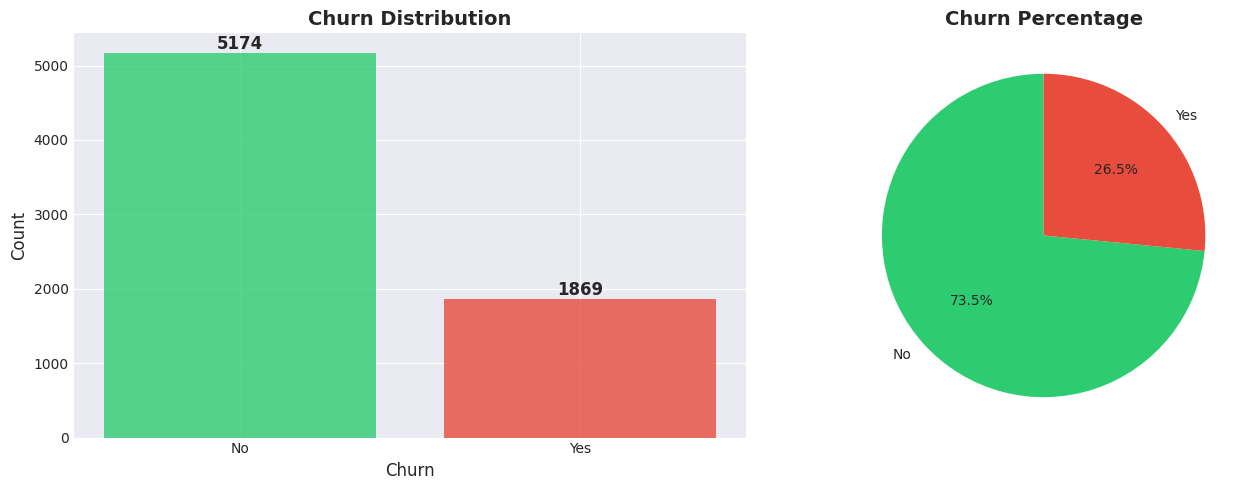

In [0]:
# Visualize Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
churn_counts = df_clean['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0].set_xlabel('Churn', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
           colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

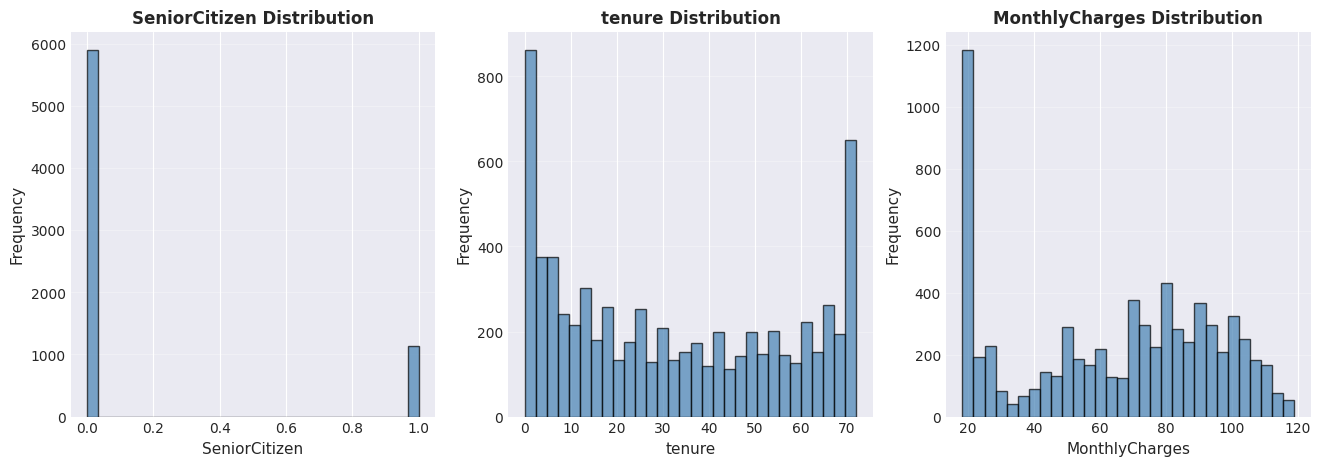

---------------------------------------------------------------------------
IndexError                                Traceback (most recent call last)
File <command-8280925849322064>, line 5
      2 fig, axes = plt.subplots(1, 3, figsize=(16, 5))
      4 for idx, feature in enumerate(numerical_features):
----> 5     axes[idx].hist(df_clean[feature], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
      6     axes[idx].set_xlabel(feature, fontsize=11)
      7     axes[idx].set_ylabel('Frequency', fontsize=11)

IndexError: index 3 is out of bounds for axis 0 with size 3

In [0]:
# Numerical features distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, feature in enumerate(numerical_features):
    axes[idx].hist(df_clean[feature], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

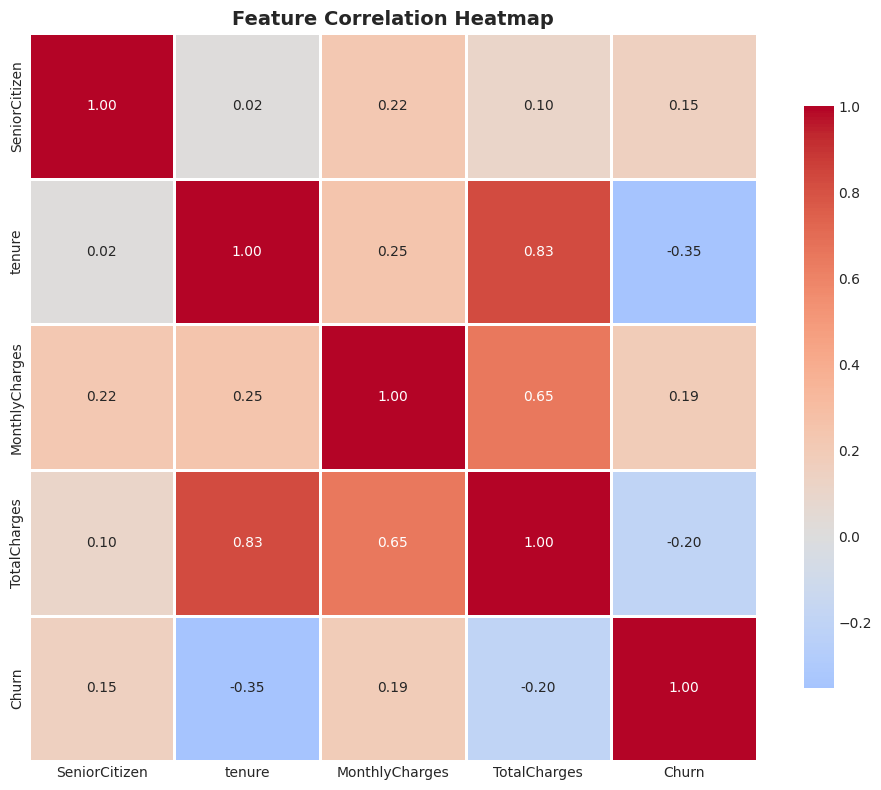

In [0]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Convert Churn to numeric for correlation
df_corr = df_clean.copy()
df_corr['Churn'] = (df_corr['Churn'] == 'Yes').astype(int)

# Calculate correlation for numerical features
corr_matrix = df_corr[numerical_features + ['Churn']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
           square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Engineering & Encoding

In [0]:
# Encode categorical features
df_encoded = df_clean.copy()

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

print(f"✓ Encoded {len(categorical_features)} categorical features")

# Encode target variable
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_encoded['Churn'])
X = df_encoded.drop('Churn', axis=1)

print(f"✓ Target encoded: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")
print(f"\nFinal dataset shape: {X.shape}")
print(f"Features: {X.columns.tolist()[:5]}...")

✓ Encoded 15 categorical features
✓ Target encoded: {'No': np.int64(0), 'Yes': np.int64(1)}

Final dataset shape: (7043, 19)
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure']...


## 4. Train-Test Split

In [0]:
# Split data (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("="*80)
print("TRAIN-TEST SPLIT")
print("="*80)
print(f"Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nClass distribution in train set:")
print(f"  No Churn: {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Churn:    {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)")

TRAIN-TEST SPLIT
Training set:   5,634 samples (80.0%)
Test set:       1,409 samples (20.0%)

Class distribution in train set:
  No Churn: 4,139 (73.5%)
  Churn:    1,495 (26.5%)


##  5. Feature Scaling

In [0]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✓ Features scaled using StandardScaler")
print(f"  Training set: {X_train_scaled.shape}")
print(f"  Test set: {X_test_scaled.shape}")

✓ Features scaled using StandardScaler
  Training set: (5634, 19)
  Test set: (1409, 19)


#  PART 2: Dimensionality Reduction

## 6. PCA (Principal Component Analysis)

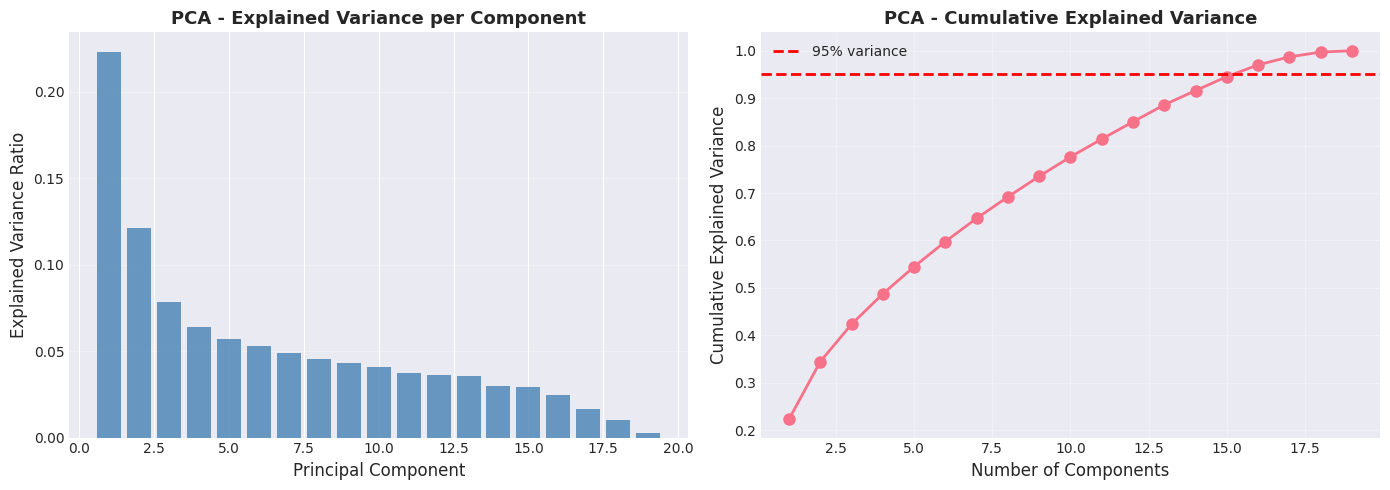


✓ 16 components explain 95% of the variance


In [0]:
from sklearn.decomposition import PCA

# Fit PCA with all components to see explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance per component
explained_var = pca_full.explained_variance_ratio_
axes[0].bar(range(1, len(explained_var) + 1), explained_var, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('PCA - Explained Variance per Component', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
cumulative_var = np.cumsum(explained_var)
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance', linewidth=2)
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('PCA - Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"\n✓ {n_components_95} components explain 95% of the variance")

✓ PCA 2D applied
  Explained variance: [0.22332988 0.12138306]
  Total variance explained: 0.3447


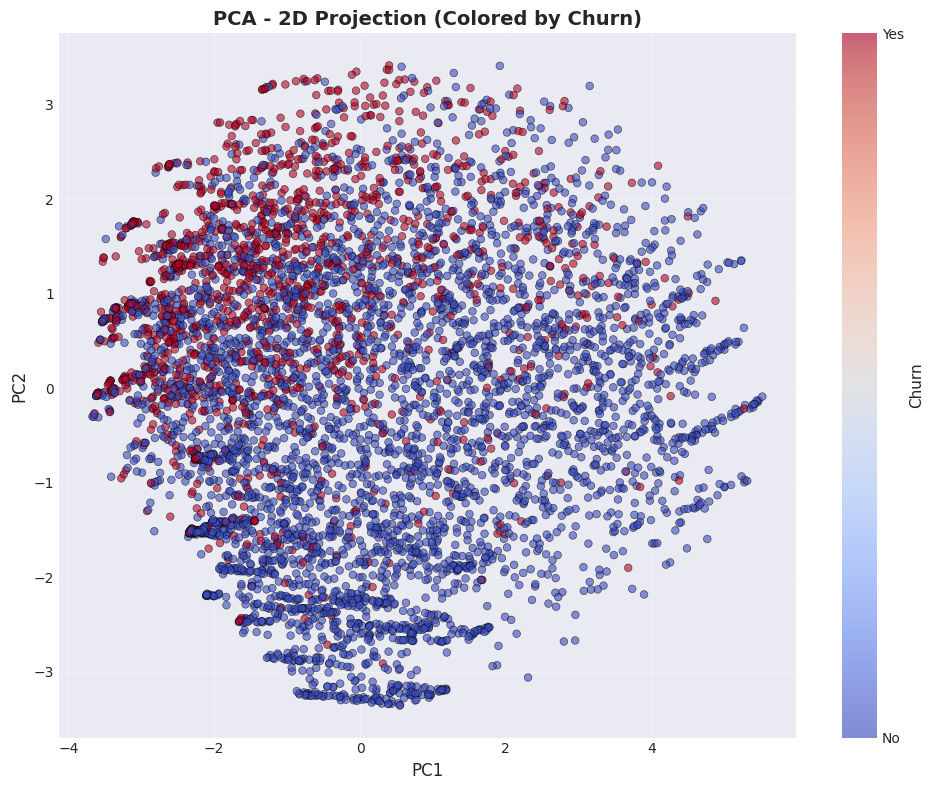

In [0]:
# Apply PCA with 2 components for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_train_scaled)

print(f"✓ PCA 2D applied")
print(f"  Explained variance: {pca_2d.explained_variance_ratio_}")
print(f"  Total variance explained: {pca_2d.explained_variance_ratio_.sum():.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA - 2D Projection (Colored by Churn)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1])
cbar.set_label('Churn', fontsize=11)
cbar.ax.set_yticklabels(['No', 'Yes'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  7. t-SNE (t-Distributed Stochastic Neighbor Embedding)

Applying t-SNE on 3000 samples...
✓ t-SNE complete!
  KL divergence: 1.3100


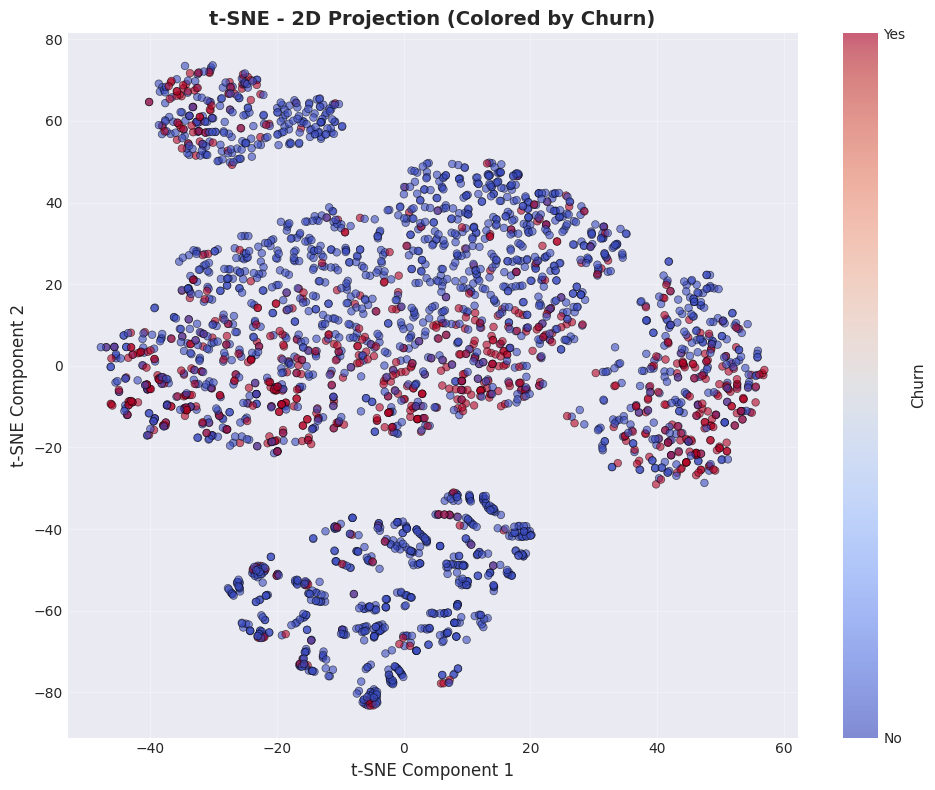

In [0]:
from sklearn.manifold import TSNE

# Apply t-SNE (subsample for speed if dataset is large)
sample_size = min(3000, len(X_train_scaled))
indices = np.random.choice(len(X_train_scaled), sample_size, replace=False)
X_train_sample = X_train_scaled.iloc[indices].values
y_train_sample = y_train[indices]

print(f"Applying t-SNE on {sample_size} samples...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=0)
X_tsne = tsne.fit_transform(X_train_sample)

print(f"✓ t-SNE complete!")
print(f"  KL divergence: {tsne.kl_divergence_:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train_sample, cmap='coolwarm', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
ax.set_xlabel('t-SNE Component 1', fontsize=12)
ax.set_ylabel('t-SNE Component 2', fontsize=12)
ax.set_title('t-SNE - 2D Projection (Colored by Churn)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1])
cbar.set_label('Churn', fontsize=11)
cbar.ax.set_yticklabels(['No', 'Yes'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  8. NMF (Non-negative Matrix Factorization)

✓ NMF complete!
  Reconstruction error: 116.7383


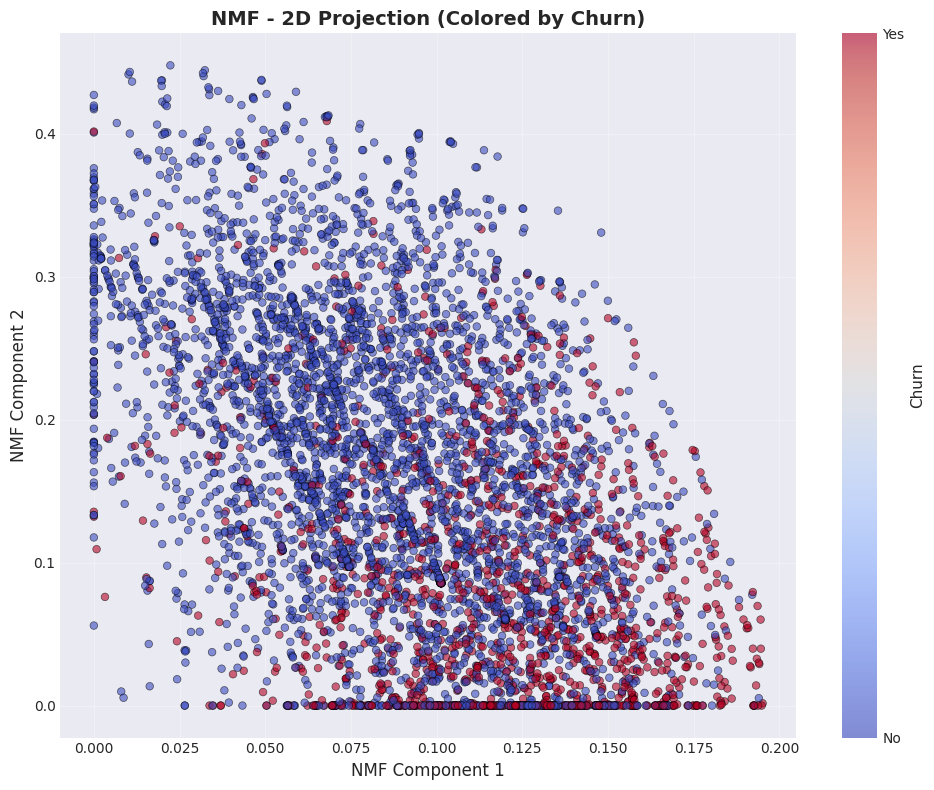

In [0]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler

# NMF requires non-negative data
minmax_scaler = MinMaxScaler()
X_train_nonneg = minmax_scaler.fit_transform(X_train)

# Apply NMF
nmf = NMF(n_components=2, random_state=42, max_iter=500)
X_nmf = nmf.fit_transform(X_train_nonneg)

print(f"✓ NMF complete!")
print(f"  Reconstruction error: {nmf.reconstruction_err_:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_nmf[:, 0], X_nmf[:, 1], c=y_train, cmap='coolwarm', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
ax.set_xlabel('NMF Component 1', fontsize=12)
ax.set_ylabel('NMF Component 2', fontsize=12)
ax.set_title('NMF - 2D Projection (Colored by Churn)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1])
cbar.set_label('Churn', fontsize=11)
cbar.ax.set_yticklabels(['No', 'Yes'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#  PART 3: Unsupervised Learning (Clustering)

##  9. K-Means Clustering

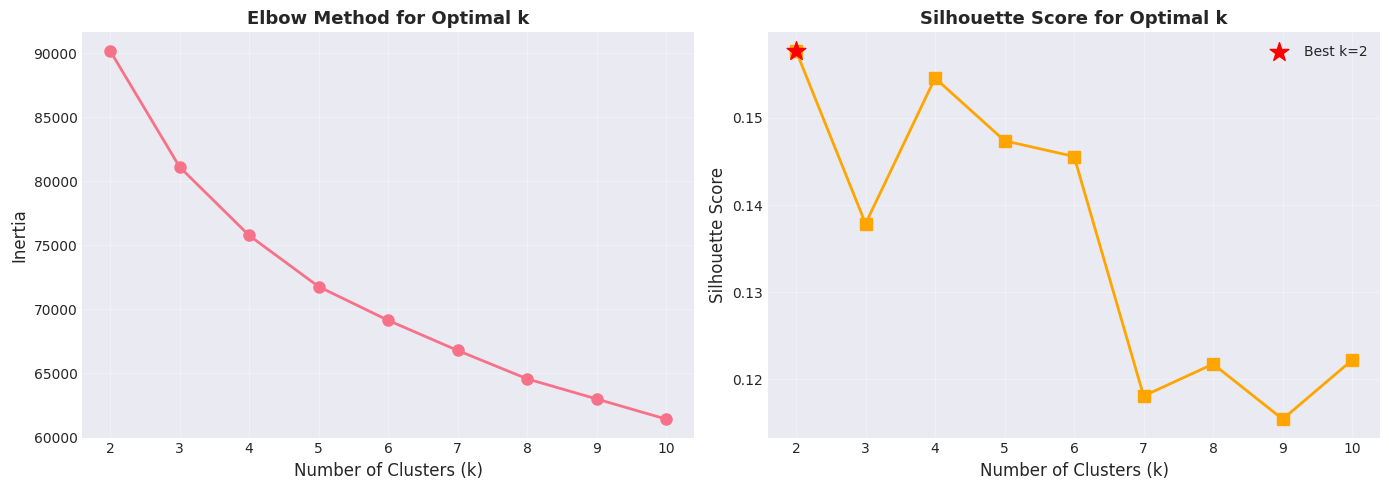

✓ Optimal k: 2 (Silhouette Score: 0.1577)


In [0]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Find optimal k using Elbow method
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, kmeans.labels_))

# Plot Elbow & Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method for Optimal k', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Optimal k', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Mark best k
best_k = k_range[np.argmax(silhouette_scores)]
axes[1].scatter([best_k], [max(silhouette_scores)], color='red', s=200, zorder=5, marker='*', label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"✓ Optimal k: {best_k} (Silhouette Score: {max(silhouette_scores):.4f})")

In [0]:
# Fit K-Means with optimal k
optimal_k = 3  # Or use best_k from above
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_train_scaled)

# Evaluation
sil_score = silhouette_score(X_train_scaled, kmeans_labels)
db_score = davies_bouldin_score(X_train_scaled, kmeans_labels)
ch_score = calinski_harabasz_score(X_train_scaled, kmeans_labels)

print("="*80)
print(f"K-MEANS CLUSTERING (k={optimal_k})")
print("="*80)
print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Index: {db_score:.4f}")
print(f"Calinski-Harabasz Score: {ch_score:.4f}")

# Compare with true labels
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
ari = adjusted_rand_score(y_train, kmeans_labels)
nmi = normalized_mutual_info_score(y_train, kmeans_labels)
print(f"\nComparison with true labels:")
print(f"  Adjusted Rand Index: {ari:.4f}")
print(f"  Normalized Mutual Info: {nmi:.4f}")

K-MEANS CLUSTERING (k=3)
Silhouette Score: 0.1379
Davies-Bouldin Index: 2.0334
Calinski-Harabasz Score: 899.5312

Comparison with true labels:
  Adjusted Rand Index: 0.0245
  Normalized Mutual Info: 0.0891


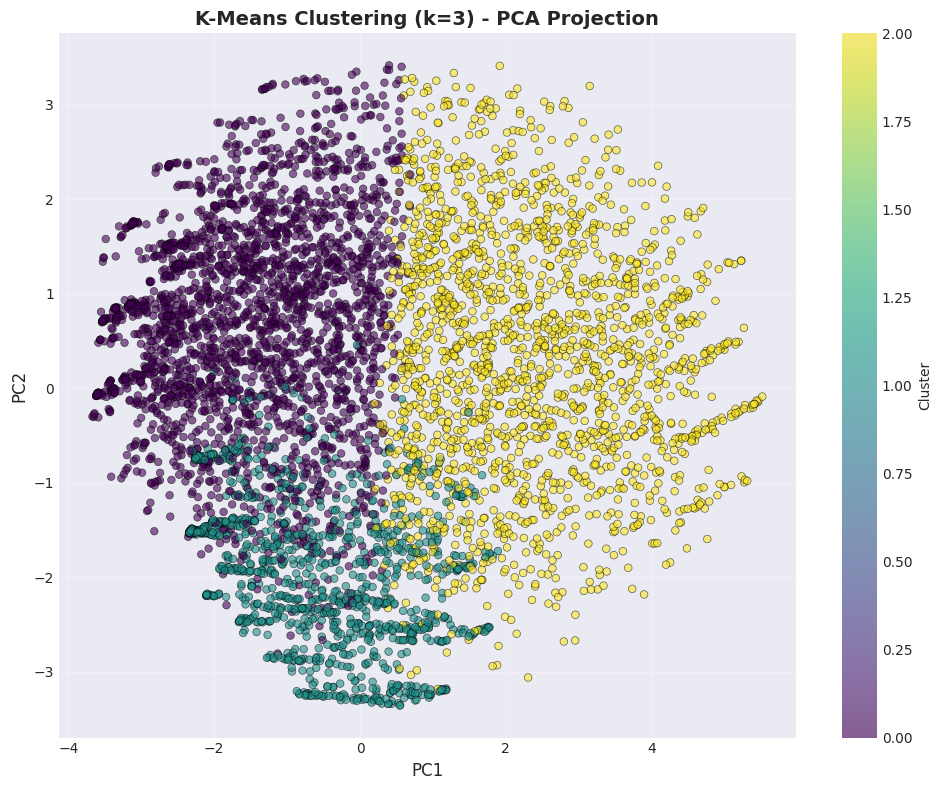

In [0]:
# Visualize clusters on PCA
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title(f'K-Means Clustering (k={optimal_k}) - PCA Projection', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  10. DBSCAN (Density-Based Clustering)

In [0]:
from sklearn.cluster import DBSCAN

# Fit DBSCAN
dbscan = DBSCAN(eps=2.0, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_train_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("="*80)
print("DBSCAN CLUSTERING")
print("="*80)
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.2f}%)")

if n_clusters_dbscan > 1:
    # Calculate metrics only for non-noise points
    mask = dbscan_labels != -1
    sil_score_dbscan = silhouette_score(X_train_scaled[mask], dbscan_labels[mask])
    print(f"Silhouette Score (non-noise): {sil_score_dbscan:.4f}")

DBSCAN CLUSTERING
Number of clusters: 65
Noise points: 3842 (68.19%)
Silhouette Score (non-noise): 0.3319


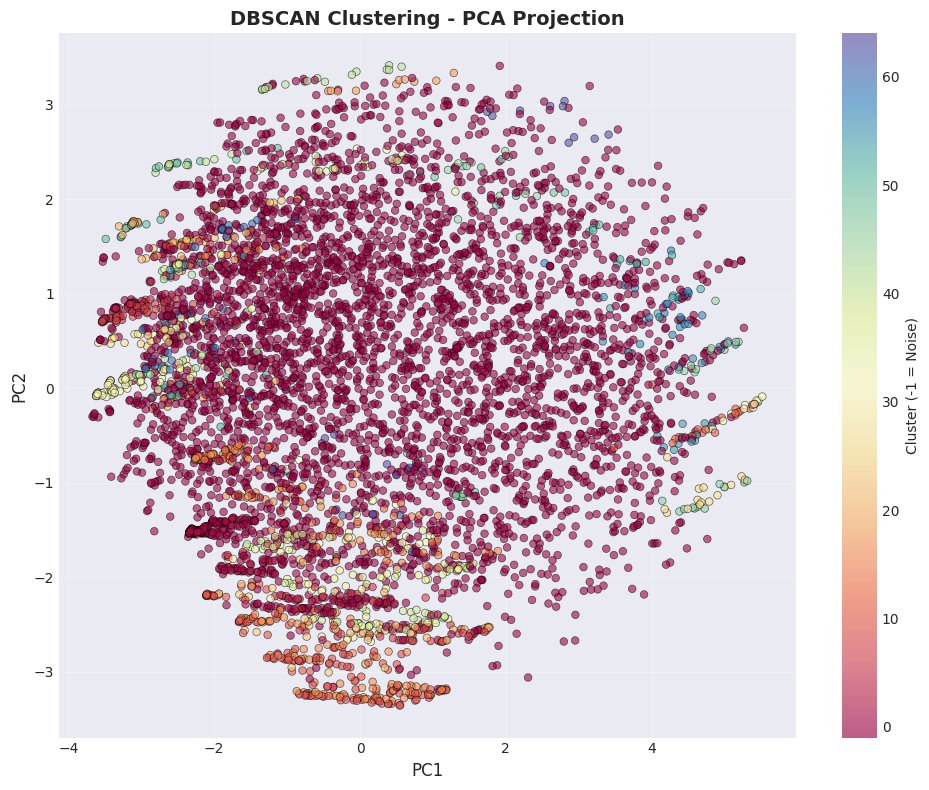

In [0]:
# Visualize DBSCAN clusters
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='Spectral', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('DBSCAN Clustering - PCA Projection', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster (-1 = Noise)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  11. Hierarchical Clustering

In [0]:
from sklearn.cluster import AgglomerativeClustering

# Fit Hierarchical Clustering
n_clusters_hier = 3
hierarchical = AgglomerativeClustering(n_clusters=n_clusters_hier, linkage='ward')
hier_labels = hierarchical.fit_predict(X_train_scaled)

# Evaluation
sil_score_hier = silhouette_score(X_train_scaled, hier_labels)
db_score_hier = davies_bouldin_score(X_train_scaled, hier_labels)

print("="*80)
print(f"HIERARCHICAL CLUSTERING (n_clusters={n_clusters_hier}, linkage='ward')")
print("="*80)
print(f"Silhouette Score: {sil_score_hier:.4f}")
print(f"Davies-Bouldin Index: {db_score_hier:.4f}")

HIERARCHICAL CLUSTERING (n_clusters=3, linkage='ward')
Silhouette Score: 0.1167
Davies-Bouldin Index: 2.1637


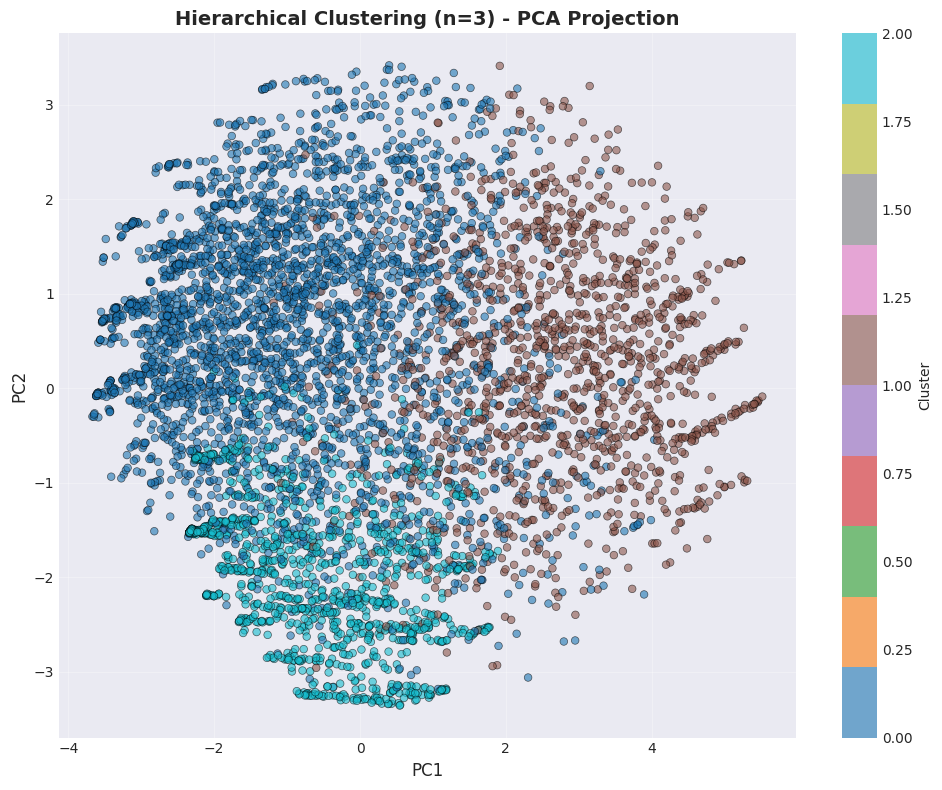

In [0]:
# Visualize hierarchical clusters
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=hier_labels, cmap='tab10', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title(f'Hierarchical Clustering (n={n_clusters_hier}) - PCA Projection', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 🤖 PART 4: Supervised Learning

##  12. Initialize MLflow Experiment

In [0]:
# Set MLflow experiment
EXPERIMENT_NAME = "/Users/fatimaezzahraaboutaleb5@gmail.com/telco-churn-ml-databricks" 
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✓ MLflow experiment set: {EXPERIMENT_NAME}")
print(f"✓ Tracking URI: {mlflow.get_tracking_uri()}")

2026/01/29 15:02:35 INFO mlflow.tracking.fluent: Experiment with name '/Users/fatimaezzahraaboutaleb5@gmail.com/telco-churn-ml-databricks' does not exist. Creating a new experiment.


✓ MLflow experiment set: /Users/fatimaezzahraaboutaleb5@gmail.com/telco-churn-ml-databricks
✓ Tracking URI: databricks


##  13. Train Base Models

In [0]:
# Helper function for model evaluation
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Evaluate model and return metrics"""
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    if hasattr(model, 'predict_proba'):
        y_test_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_test_proba = model.decision_function(X_test)
    
    metrics = {
        'model_name': model_name,
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'test_precision': precision_score(y_test, y_test_pred, zero_division=0),
        'test_recall': recall_score(y_test, y_test_pred, zero_division=0),
        'test_f1': f1_score(y_test, y_test_pred, zero_division=0),
        'test_roc_auc': roc_auc_score(y_test, y_test_proba)
    }
    
    return metrics, y_test_pred, y_test_proba

# Storage for results
all_metrics = []
all_predictions = {}
all_roc_data = {}

### 13.1 Logistic Regression

In [0]:
from sklearn.linear_model import LogisticRegression

with mlflow.start_run(run_name="Logistic_Regression"):
    print("Training Logistic Regression...")
    
    # Parameters
    C = 1.0
    max_iter = 1000
    mlflow.log_param("C", C)
    mlflow.log_param("max_iter", max_iter)
    
    # Train
    lr_model = LogisticRegression(C=C, max_iter=max_iter, random_state=42)
    lr_model.fit(X_train_scaled, y_train)
    
    # Evaluate
    metrics, y_pred, y_proba = evaluate_model(lr_model, X_train_scaled, y_train, 
                                              X_test_scaled, y_test, "Logistic Regression")
    
    # Log metrics
    for metric_name, value in metrics.items():
        if metric_name != 'model_name':
            mlflow.log_metric(metric_name, value)
    
    # Log model
    mlflow.sklearn.log_model(lr_model, "logistic_regression_model")
    
    # Store results
    all_metrics.append(metrics)
    all_predictions['Logistic Regression'] = (y_test, y_pred)
    all_roc_data['Logistic Regression'] = (y_test, y_proba)
    
    print(f"✓ Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"✓ F1-Score: {metrics['test_f1']:.4f}")
    print(f"✓ ROC-AUC: {metrics['test_roc_auc']:.4f}")

Training Logistic Regression...


2026/01/29 15:02:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-a8bd32e0-2554.cloud.databricks.com/ml/experiments/2190309582370989/models/m-d08c6dc513bd469c9a42fcdcd924e6fe?o=7474651403819585
2026/01/29 15:02:52 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.9.0/ml/model/signatures.html for instructions on setting signature on models.


✓ Test Accuracy: 0.7991
✓ F1-Score: 0.5916
✓ ROC-AUC: 0.8403


### 13.2 Support Vector Machine (SVM)

In [0]:
from sklearn.svm import SVC

with mlflow.start_run(run_name="SVM_RBF"):
    print("Training SVM (RBF kernel)...")
    
    # Parameters
    kernel = 'rbf'
    C = 1.0
    gamma = 'scale'
    mlflow.log_param("kernel", kernel)
    mlflow.log_param("C", C)
    mlflow.log_param("gamma", gamma)
    
    # Train
    svm_model = SVC(kernel=kernel, C=C, gamma=gamma, probability=True, random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    
    # Evaluate
    metrics, y_pred, y_proba = evaluate_model(svm_model, X_train_scaled, y_train,
                                              X_test_scaled, y_test, "SVM (RBF)")
    
    # Log metrics
    for metric_name, value in metrics.items():
        if metric_name != 'model_name':
            mlflow.log_metric(metric_name, value)
    
    # Log model
    mlflow.sklearn.log_model(svm_model, "svm_model")
    
    # Store results
    all_metrics.append(metrics)
    all_predictions['SVM (RBF)'] = (y_test, y_pred)
    all_roc_data['SVM (RBF)'] = (y_test, y_proba)
    
    print(f"✓ Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"✓ F1-Score: {metrics['test_f1']:.4f}")
    print(f"✓ ROC-AUC: {metrics['test_roc_auc']:.4f}")

Training SVM (RBF kernel)...


2026/01/29 15:02:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-a8bd32e0-2554.cloud.databricks.com/ml/experiments/2190309582370989/models/m-40f2a33e008d4939be5aebfa502647a1?o=7474651403819585
2026/01/29 15:03:02 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.9.0/ml/model/signatures.html for instructions on setting signature on models.


✓ Test Accuracy: 0.7935
✓ F1-Score: 0.5516
✓ ROC-AUC: 0.7909


### 13.3 K-Nearest Neighbors (KNN)

In [0]:
from sklearn.neighbors import KNeighborsClassifier

with mlflow.start_run(run_name="KNN"):
    print("Training K-Nearest Neighbors...")
    
    # Parameters
    n_neighbors = 5
    weights = 'uniform'
    mlflow.log_param("n_neighbors", n_neighbors)
    mlflow.log_param("weights", weights)
    
    # Train
    knn_model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)
    knn_model.fit(X_train_scaled, y_train)
    
    # Evaluate
    metrics, y_pred, y_proba = evaluate_model(knn_model, X_train_scaled, y_train,
                                              X_test_scaled, y_test, "KNN (k=5)")
    
    # Log metrics
    for metric_name, value in metrics.items():
        if metric_name != 'model_name':
            mlflow.log_metric(metric_name, value)
    
    # Log model
    mlflow.sklearn.log_model(knn_model, "knn_model")
    
    # Store results
    all_metrics.append(metrics)
    all_predictions['KNN (k=5)'] = (y_test, y_pred)
    all_roc_data['KNN (k=5)'] = (y_test, y_proba)
    
    print(f"✓ Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"✓ F1-Score: {metrics['test_f1']:.4f}")
    print(f"✓ ROC-AUC: {metrics['test_roc_auc']:.4f}")

Training K-Nearest Neighbors...


2026/01/29 15:03:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-a8bd32e0-2554.cloud.databricks.com/ml/experiments/2190309582370989/models/m-fd2739abb7d84cccb7685839aaf2cfe1?o=7474651403819585
2026/01/29 15:03:08 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.9.0/ml/model/signatures.html for instructions on setting signature on models.


✓ Test Accuracy: 0.7424
✓ F1-Score: 0.5088
✓ ROC-AUC: 0.7605


##  14. Tree-Based Models

### 14.1 Decision Tree

In [0]:
from sklearn.tree import DecisionTreeClassifier

with mlflow.start_run(run_name="Decision_Tree"):
    print("Training Decision Tree...")
    
    # Parameters
    max_depth = 5
    min_samples_split = 50
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("min_samples_split", min_samples_split)
    
    # Train
    dt_model = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
    dt_model.fit(X_train_scaled, y_train)
    
    # Evaluate
    metrics, y_pred, y_proba = evaluate_model(dt_model, X_train_scaled, y_train,
                                              X_test_scaled, y_test, "Decision Tree")
    
    # Log metrics
    for metric_name, value in metrics.items():
        if metric_name != 'model_name':
            mlflow.log_metric(metric_name, value)
    
    # Log model
    mlflow.sklearn.log_model(dt_model, "decision_tree_model")
    
    # Store results
    all_metrics.append(metrics)
    all_predictions['Decision Tree'] = (y_test, y_pred)
    all_roc_data['Decision Tree'] = (y_test, y_proba)
    
    print(f"✓ Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"✓ F1-Score: {metrics['test_f1']:.4f}")
    print(f"✓ ROC-AUC: {metrics['test_roc_auc']:.4f}")

Training Decision Tree...


2026/01/29 15:03:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-a8bd32e0-2554.cloud.databricks.com/ml/experiments/2190309582370989/models/m-06047e2733f24cacb80ef81cef7bd53c?o=7474651403819585
2026/01/29 15:03:13 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.9.0/ml/model/signatures.html for instructions on setting signature on models.


✓ Test Accuracy: 0.7850
✓ F1-Score: 0.5774
✓ ROC-AUC: 0.8217


##  15. Ensemble Methods

### 15.1 Random Forest (Bagging)

In [0]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="Random_Forest"):
    print("Training Random Forest...")
    
    # Parameters
    n_estimators = 100
    max_depth = 10
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("ensemble_method", "Bagging")
    
    # Train
    rf_model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    rf_model.fit(X_train_scaled, y_train)
    
    # Evaluate
    metrics, y_pred, y_proba = evaluate_model(rf_model, X_train_scaled, y_train,
                                              X_test_scaled, y_test, "Random Forest")
    
    # Log metrics
    for metric_name, value in metrics.items():
        if metric_name != 'model_name':
            mlflow.log_metric(metric_name, value)
    
    # Log model
    mlflow.sklearn.log_model(rf_model, "random_forest_model")
    
    # Store results
    all_metrics.append(metrics)
    all_predictions['Random Forest'] = (y_test, y_pred)
    all_roc_data['Random Forest'] = (y_test, y_proba)
    
    print(f"✓ Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"✓ F1-Score: {metrics['test_f1']:.4f}")
    print(f"✓ ROC-AUC: {metrics['test_roc_auc']:.4f}")

Training Random Forest...


2026/01/29 15:03:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-a8bd32e0-2554.cloud.databricks.com/ml/experiments/2190309582370989/models/m-7885975206514e699678379df7234a56?o=7474651403819585
2026/01/29 15:03:19 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.9.0/ml/model/signatures.html for instructions on setting signature on models.


✓ Test Accuracy: 0.7963
✓ F1-Score: 0.5697
✓ ROC-AUC: 0.8356


### 15.2 AdaBoost (Boosting)

In [0]:
from sklearn.ensemble import AdaBoostClassifier

with mlflow.start_run(run_name="AdaBoost"):
    print("Training AdaBoost...")
    
    # Parameters
    n_estimators = 50
    learning_rate = 1.0
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("ensemble_method", "Boosting")
    
    # Train
    ada_model = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate, random_state=42)
    ada_model.fit(X_train_scaled, y_train)
    
    # Evaluate
    metrics, y_pred, y_proba = evaluate_model(ada_model, X_train_scaled, y_train,
                                              X_test_scaled, y_test, "AdaBoost")
    
    # Log metrics
    for metric_name, value in metrics.items():
        if metric_name != 'model_name':
            mlflow.log_metric(metric_name, value)
    
    # Log model
    mlflow.sklearn.log_model(ada_model, "adaboost_model")
    
    # Store results
    all_metrics.append(metrics)
    all_predictions['AdaBoost'] = (y_test, y_pred)
    all_roc_data['AdaBoost'] = (y_test, y_proba)
    
    print(f"✓ Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"✓ F1-Score: {metrics['test_f1']:.4f}")
    print(f"✓ ROC-AUC: {metrics['test_roc_auc']:.4f}")

Training AdaBoost...


2026/01/29 15:03:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-a8bd32e0-2554.cloud.databricks.com/ml/experiments/2190309582370989/models/m-fc420db2013b421bac9d6046baadb435?o=7474651403819585
2026/01/29 15:03:25 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.9.0/ml/model/signatures.html for instructions on setting signature on models.


✓ Test Accuracy: 0.7949
✓ F1-Score: 0.5781
✓ ROC-AUC: 0.8432


### 15.3 Gradient Boosting

In [0]:
from sklearn.ensemble import GradientBoostingClassifier

with mlflow.start_run(run_name="Gradient_Boosting"):
    print("Training Gradient Boosting...")
    
    # Parameters
    n_estimators = 100
    learning_rate = 0.1
    max_depth = 3
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("ensemble_method", "Boosting")
    
    # Train
    gb_model = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=learning_rate,
                                         max_depth=max_depth, random_state=42)
    gb_model.fit(X_train_scaled, y_train)
    
    # Evaluate
    metrics, y_pred, y_proba = evaluate_model(gb_model, X_train_scaled, y_train,
                                              X_test_scaled, y_test, "Gradient Boosting")
    
    # Log metrics
    for metric_name, value in metrics.items():
        if metric_name != 'model_name':
            mlflow.log_metric(metric_name, value)
    
    # Log model
    mlflow.sklearn.log_model(gb_model, "gradient_boosting_model")
    
    # Store results
    all_metrics.append(metrics)
    all_predictions['Gradient Boosting'] = (y_test, y_pred)
    all_roc_data['Gradient Boosting'] = (y_test, y_proba)
    
    print(f"✓ Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"✓ F1-Score: {metrics['test_f1']:.4f}")
    print(f"✓ ROC-AUC: {metrics['test_roc_auc']:.4f}")

Training Gradient Boosting...


2026/01/29 15:03:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-a8bd32e0-2554.cloud.databricks.com/ml/experiments/2190309582370989/models/m-984504526c1640bbadfe251e69734cfd?o=7474651403819585
2026/01/29 15:03:31 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.9.0/ml/model/signatures.html for instructions on setting signature on models.


✓ Test Accuracy: 0.8013
✓ F1-Score: 0.5745
✓ ROC-AUC: 0.8447


### 15.4 XGBoost

In [0]:
try:
    import xgboost as xgb
    
    with mlflow.start_run(run_name="XGBoost"):
        print("Training XGBoost...")
        
        # Parameters
        n_estimators = 100
        learning_rate = 0.1
        max_depth = 3
        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("max_depth", max_depth)
        mlflow.log_param("ensemble_method", "Boosting")
        
        # Train
        xgb_model = xgb.XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate,
                                     max_depth=max_depth, random_state=42, eval_metric='logloss')
        xgb_model.fit(X_train_scaled, y_train)
        
        # Evaluate
        metrics, y_pred, y_proba = evaluate_model(xgb_model, X_train_scaled, y_train,
                                                  X_test_scaled, y_test, "XGBoost")
        
        # Log metrics
        for metric_name, value in metrics.items():
            if metric_name != 'model_name':
                mlflow.log_metric(metric_name, value)
        
        # Log model
        mlflow.xgboost.log_model(xgb_model, "xgboost_model")
        
        # Store results
        all_metrics.append(metrics)
        all_predictions['XGBoost'] = (y_test, y_pred)
        all_roc_data['XGBoost'] = (y_test, y_proba)
        
        print(f"✓ Test Accuracy: {metrics['test_accuracy']:.4f}")
        print(f"✓ F1-Score: {metrics['test_f1']:.4f}")
        print(f"✓ ROC-AUC: {metrics['test_roc_auc']:.4f}")
        
except ImportError:
    print("⚠ XGBoost not available. Install with: %pip install xgboost")

Training XGBoost...


2026/01/29 15:03:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-a8bd32e0-2554.cloud.databricks.com/ml/experiments/2190309582370989/models/m-381ab2635a7849218ef4267ed36eb01d?o=7474651403819585
2026/01/29 15:03:38 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.9.0/ml/model/signatures.html for instructions on setting signature on models.


✓ Test Accuracy: 0.8055
✓ F1-Score: 0.5910
✓ ROC-AUC: 0.8439


# PART 5: Neural Network (Deep Learning)

## 16. Build and Train Neural Network

✓ TensorFlow version: 2.20.0

Building Neural Network...



Model: "Churn_Prediction_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (Dense)           │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,377 (52.25 KB)

 Non-trainable params: 448 (1.75 KB)


Training Neural Network...
Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6840 - auc: 0.7345 - loss: 0.6165 - precision: 0.4360 - recall: 0.6358 - val_accuracy: 0.7808 - val_auc: 0.8072 - val_loss: 0.4909 - val_precision: 0.6091 - val_recall: 0.4542 - learning_rate: 0.0010
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7575 - auc: 0.7858 - loss: 0.5027 - precision: 0.5430 - recall: 0.5633 - val_accuracy: 0.7826 - val_auc: 0.8138 - val_loss: 0.4581 - val_precision: 0.5919 - val_recall: 0.5458 - learning_rate: 0.0010
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7808 - auc: 0.8099 - loss: 0.4648 - precision: 0.5952 - recall: 0.5525 - val_accuracy: 0.7835 - val_auc: 0.8155 - val_loss: 0.4478 - val_precision: 0.6008 - val_recall: 0.5153 - learning_rate: 0.0010
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7819 - auc: 0.8136 - loss: 0.4545 - precision: 0.6115 - recall: 0.4958 - val_accuracy: 0.7835 - val_auc: 0.8

2026/01/29 15:03:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-a8bd32e0-2554.cloud.databricks.com/ml/experiments/2190309582370989/models/m-1e76617aab2c4b9f80ddd71052388236?o=7474651403819585
2026/01/29 15:03:58 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/01/29 15:04:04 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.9.0/ml/model/signatures.html for instructions on setting signature on models.



NEURAL NETWORK RESULTS
Test Accuracy:  0.7935
Precision:      0.6370
Recall:         0.5160
F1-Score:       0.5702
ROC-AUC:        0.8346


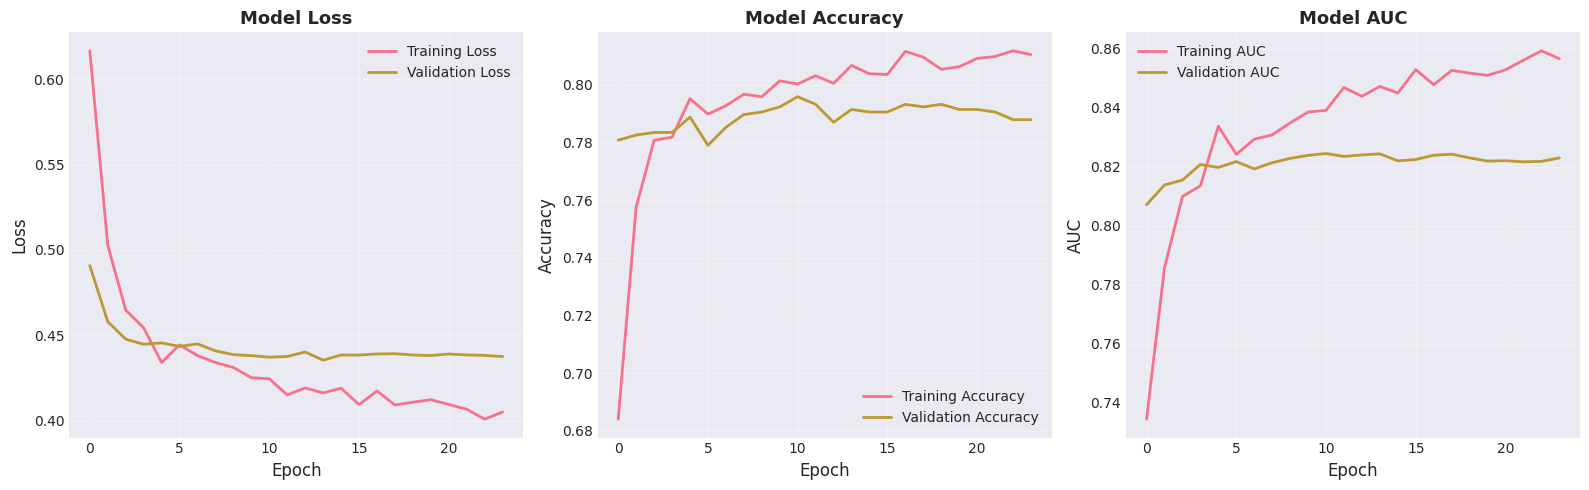

In [0]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    
    print(f"✓ TensorFlow version: {tf.__version__}")
    
    with mlflow.start_run(run_name="Neural_Network"):
        print("\nBuilding Neural Network...")
        
        # Parameters
        hidden_layers = [128, 64, 32]
        dropout_rate = 0.3
        learning_rate = 0.001
        epochs = 50
        batch_size = 32
        
        mlflow.log_param("hidden_layers", str(hidden_layers))
        mlflow.log_param("dropout_rate", dropout_rate)
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("batch_size", batch_size)
        
        # Build model
        model = Sequential(name='Churn_Prediction_NN')
        
        # Input layer
        model.add(Dense(hidden_layers[0], activation='relu', input_dim=X_train_scaled.shape[1], name='input_layer_1'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
        
        # Hidden layers
        for idx, units in enumerate(hidden_layers[1:], start=2):
            model.add(Dense(units, activation='relu', name=f'hidden_layer_{idx}'))
            model.add(BatchNormalization())
            model.add(Dropout(dropout_rate))
        
        # Output layer
        model.add(Dense(1, activation='sigmoid', name='output_layer'))
        
        # Compile
        optimizer = Adam(learning_rate=learning_rate)
        model.compile(optimizer=optimizer,
                     loss='binary_crossentropy',
                     metrics=['accuracy',
                             keras.metrics.Precision(name='precision'),
                             keras.metrics.Recall(name='recall'),
                             keras.metrics.AUC(name='auc')])
        
        print("\n" + "="*80)
        model.summary()
        print("="*80 + "\n")
        
        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
        
        # Train
        print("Training Neural Network...")
        history = model.fit(
            X_train_scaled, y_train,
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )
        
        # Evaluate
        print("\nEvaluating on test set...")
        y_pred_proba = model.predict(X_test_scaled, verbose=0).flatten()
        y_pred = (y_pred_proba >= 0.5).astype(int)
        
        nn_metrics = {
            'model_name': 'Neural Network',
            'train_accuracy': history.history['accuracy'][-1],
            'test_accuracy': accuracy_score(y_test, y_pred),
            'test_precision': precision_score(y_test, y_pred, zero_division=0),
            'test_recall': recall_score(y_test, y_pred, zero_division=0),
            'test_f1': f1_score(y_test, y_pred, zero_division=0),
            'test_roc_auc': roc_auc_score(y_test, y_pred_proba)
        }
        
        # Log metrics
        for metric_name, value in nn_metrics.items():
            if metric_name != 'model_name':
                mlflow.log_metric(metric_name, value)
        
        # Log model
        mlflow.tensorflow.log_model(model, "neural_network_model")
        
        # Store results
        all_metrics.append(nn_metrics)
        all_predictions['Neural Network'] = (y_test, y_pred)
        all_roc_data['Neural Network'] = (y_test, y_pred_proba)
        
        print("\n" + "="*80)
        print("NEURAL NETWORK RESULTS")
        print("="*80)
        print(f"Test Accuracy:  {nn_metrics['test_accuracy']:.4f}")
        print(f"Precision:      {nn_metrics['test_precision']:.4f}")
        print(f"Recall:         {nn_metrics['test_recall']:.4f}")
        print(f"F1-Score:       {nn_metrics['test_f1']:.4f}")
        print(f"ROC-AUC:        {nn_metrics['test_roc_auc']:.4f}")
        print("="*80)
        
        # Plot training history
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        
        # Loss
        axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
        axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
        axes[0].set_xlabel('Epoch', fontsize=12)
        axes[0].set_ylabel('Loss', fontsize=12)
        axes[0].set_title('Model Loss', fontsize=13, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Accuracy
        axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
        axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
        axes[1].set_xlabel('Epoch', fontsize=12)
        axes[1].set_ylabel('Accuracy', fontsize=12)
        axes[1].set_title('Model Accuracy', fontsize=13, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # AUC
        axes[2].plot(history.history['auc'], label='Training AUC', linewidth=2)
        axes[2].plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
        axes[2].set_xlabel('Epoch', fontsize=12)
        axes[2].set_ylabel('AUC', fontsize=12)
        axes[2].set_title('Model AUC', fontsize=13, fontweight='bold')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
except ImportError as e:
    print(f"⚠ TensorFlow not available: {e}")
    print("Install with: %pip install tensorflow")


# PART 6: Model Comparison & Evaluation

## 17. Final Model Comparison

In [0]:
# Create comparison DataFrame
df_comparison = pd.DataFrame(all_metrics)
df_comparison = df_comparison.sort_values('test_accuracy', ascending=False).reset_index(drop=True)
df_comparison.insert(0, 'Rank', range(1, len(df_comparison) + 1))

print("\n" + "="*120)
print("FINAL MODEL COMPARISON - ALL ALGORITHMS")
print("="*120)
display(df_comparison)
print("="*120)

# Best model
best_model = df_comparison.iloc[0]
print(f"\nBEST MODEL: {best_model['model_name']}")
print(f"   Test Accuracy: {best_model['test_accuracy']:.4f}")
print(f"   F1-Score: {best_model['test_f1']:.4f}")
print(f"   ROC-AUC: {best_model['test_roc_auc']:.4f}")
print("="*120 + "\n")


FINAL MODEL COMPARISON - ALL ALGORITHMS


Rank,model_name,train_accuracy,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
1,XGBoost,0.8210862619808307,0.8055358410220014,0.668918918918919,0.5294117647058824,0.591044776119403,0.8439393939393939
2,Gradient Boosting,0.8292509762158324,0.801277501774308,0.6654929577464789,0.5053475935828877,0.574468085106383,0.8447479914231832
3,Logistic Regression,0.8040468583599574,0.7991483321504613,0.6426332288401254,0.5481283422459893,0.5916305916305916,0.8402800382340025
4,Random Forest,0.8844515441959532,0.7963094393186657,0.6484641638225256,0.5080213903743316,0.5697151424287856,0.835622206721951
5,AdaBoost,0.8074192403265885,0.794889992902768,0.6366559485530546,0.5294117647058824,0.5781021897810219,0.8432082978118782
6,SVM (RBF),0.8235711750088747,0.7934705464868701,0.6509090909090909,0.4786096256684492,0.551617873651772,0.7908703402309539
7,Neural Network,0.8105169534683228,0.7934705464868701,0.636963696369637,0.516042780748663,0.5701624815361891,0.8346353561187321
8,Decision Tree,0.8042243521476748,0.7849538679914834,0.6034985422740525,0.553475935828877,0.5774058577405857,0.8217417138133251
9,KNN (k=5),0.8343982960596379,0.7423704755145494,0.5150684931506849,0.5026737967914439,0.5087956698240866,0.7605130589785322



BEST MODEL: XGBoost
   Test Accuracy: 0.8055
   F1-Score: 0.5910
   ROC-AUC: 0.8439



## 18. Visualizations

### 18.1 ROC Curves Comparison

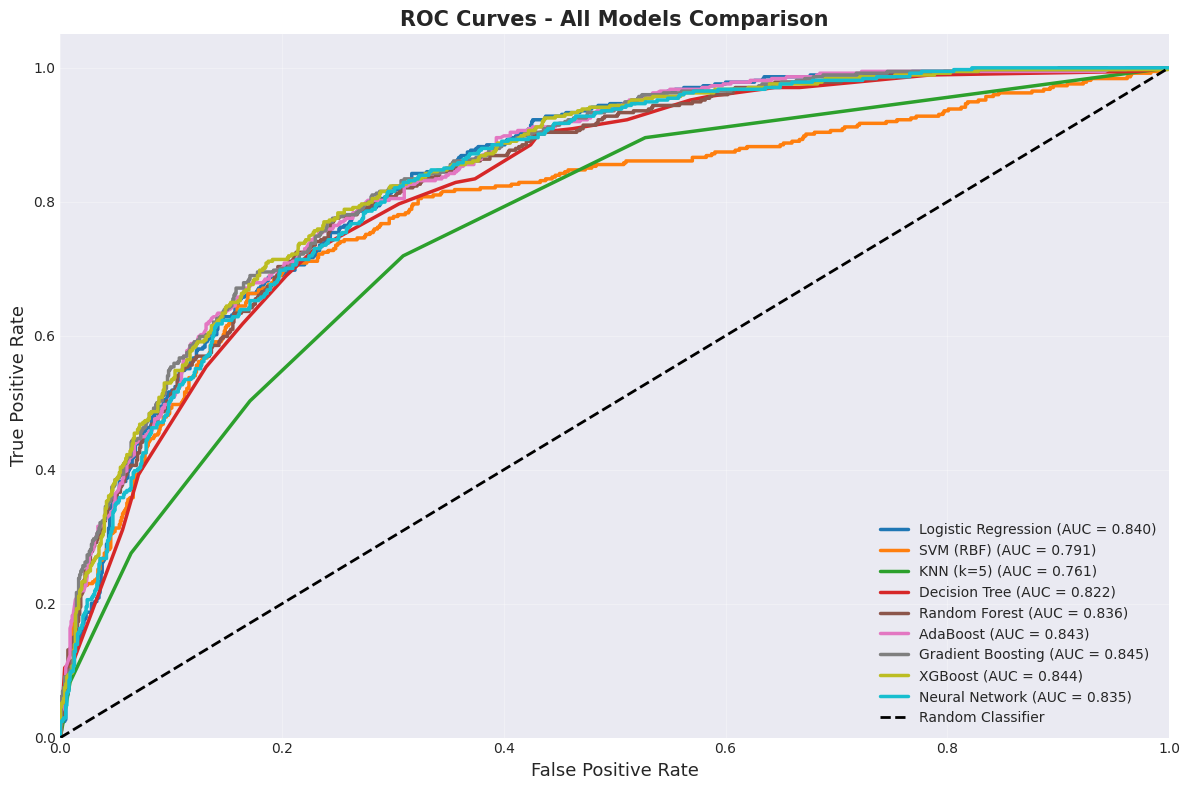

In [0]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(all_roc_data)))

for idx, (model_name, (y_true, y_proba)) in enumerate(all_roc_data.items()):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    ax.plot(fpr, tpr, linewidth=2.5, color=colors[idx],
           label=f'{model_name} (AUC = {roc_auc:.3f})')

# Diagonal line
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves - All Models Comparison', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

### 18.2 Performance Metrics Bar Charts

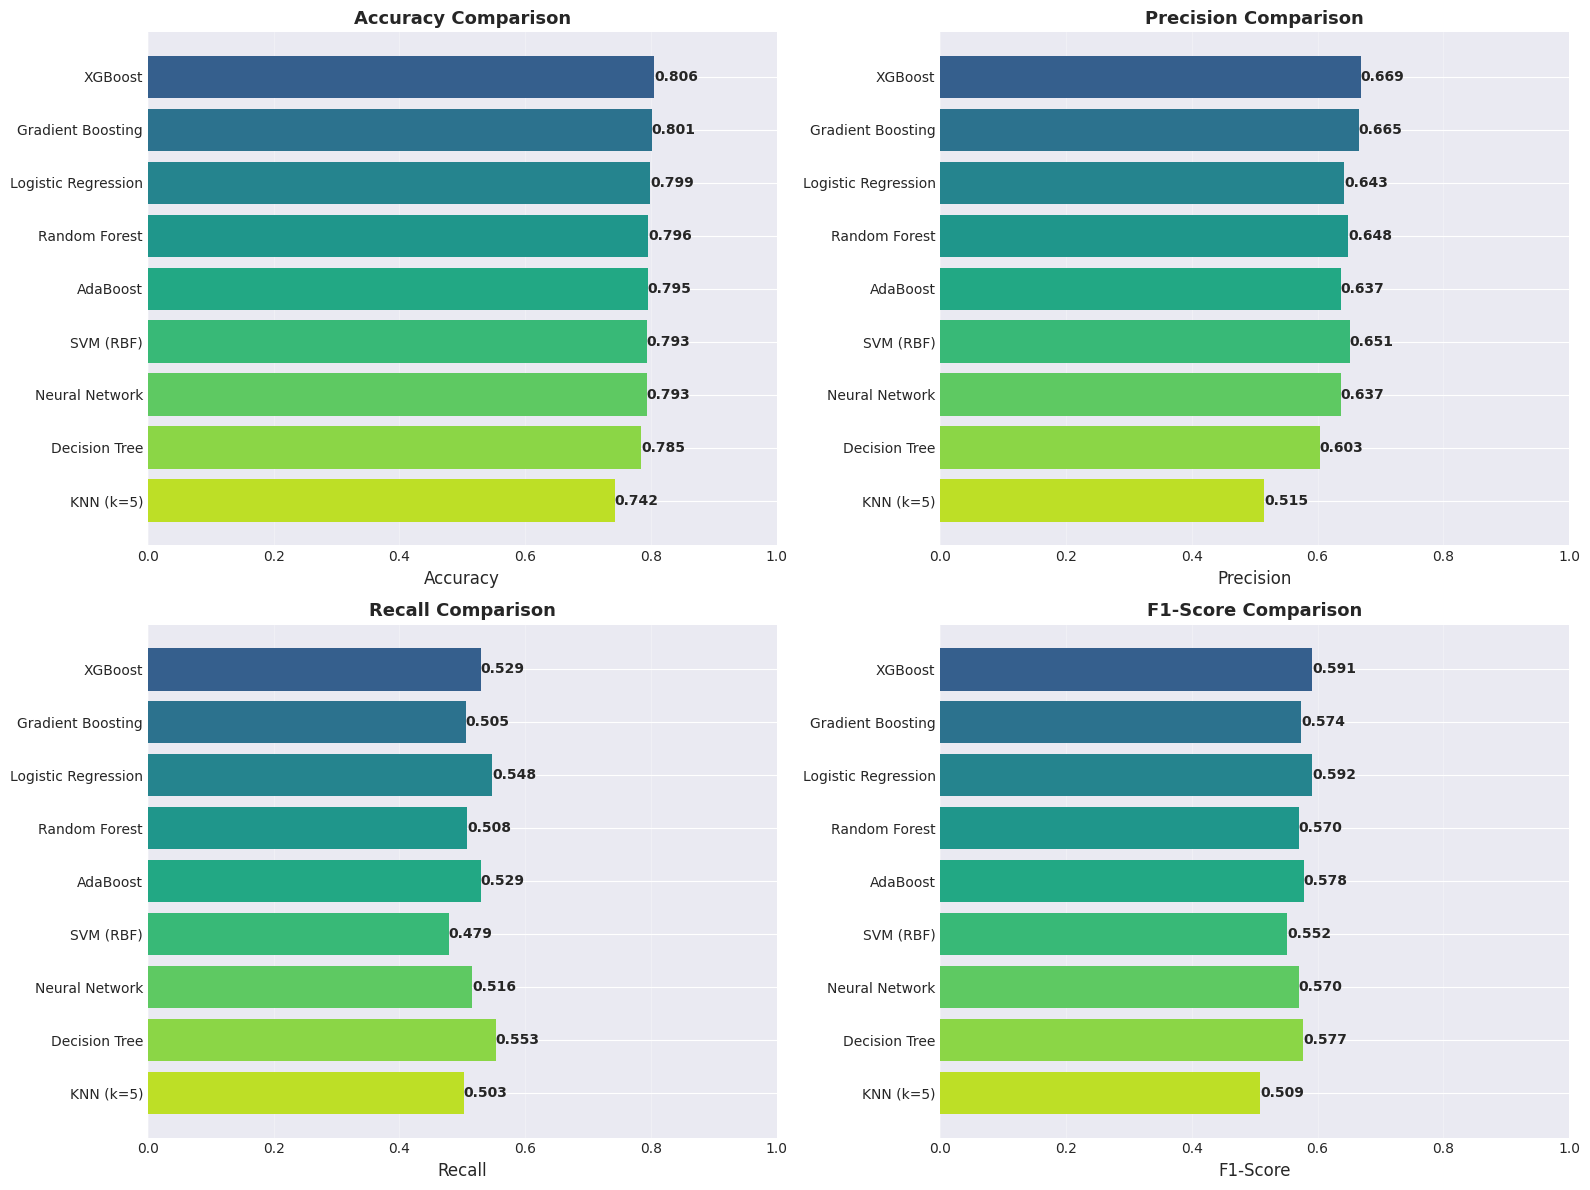

In [0]:
metrics_to_plot = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (metric, name) in enumerate(zip(metrics_to_plot, metric_names)):
    ax = axes[idx]
    colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, len(df_comparison)))
    
    bars = ax.barh(df_comparison['model_name'], df_comparison[metric], color=colors_gradient)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2,
               f'{width:.3f}', ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel(name, fontsize=12)
    ax.set_title(f'{name} Comparison', fontsize=13, fontweight='bold')
    ax.set_xlim([0, 1.0])
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 18.3 Confusion Matrices

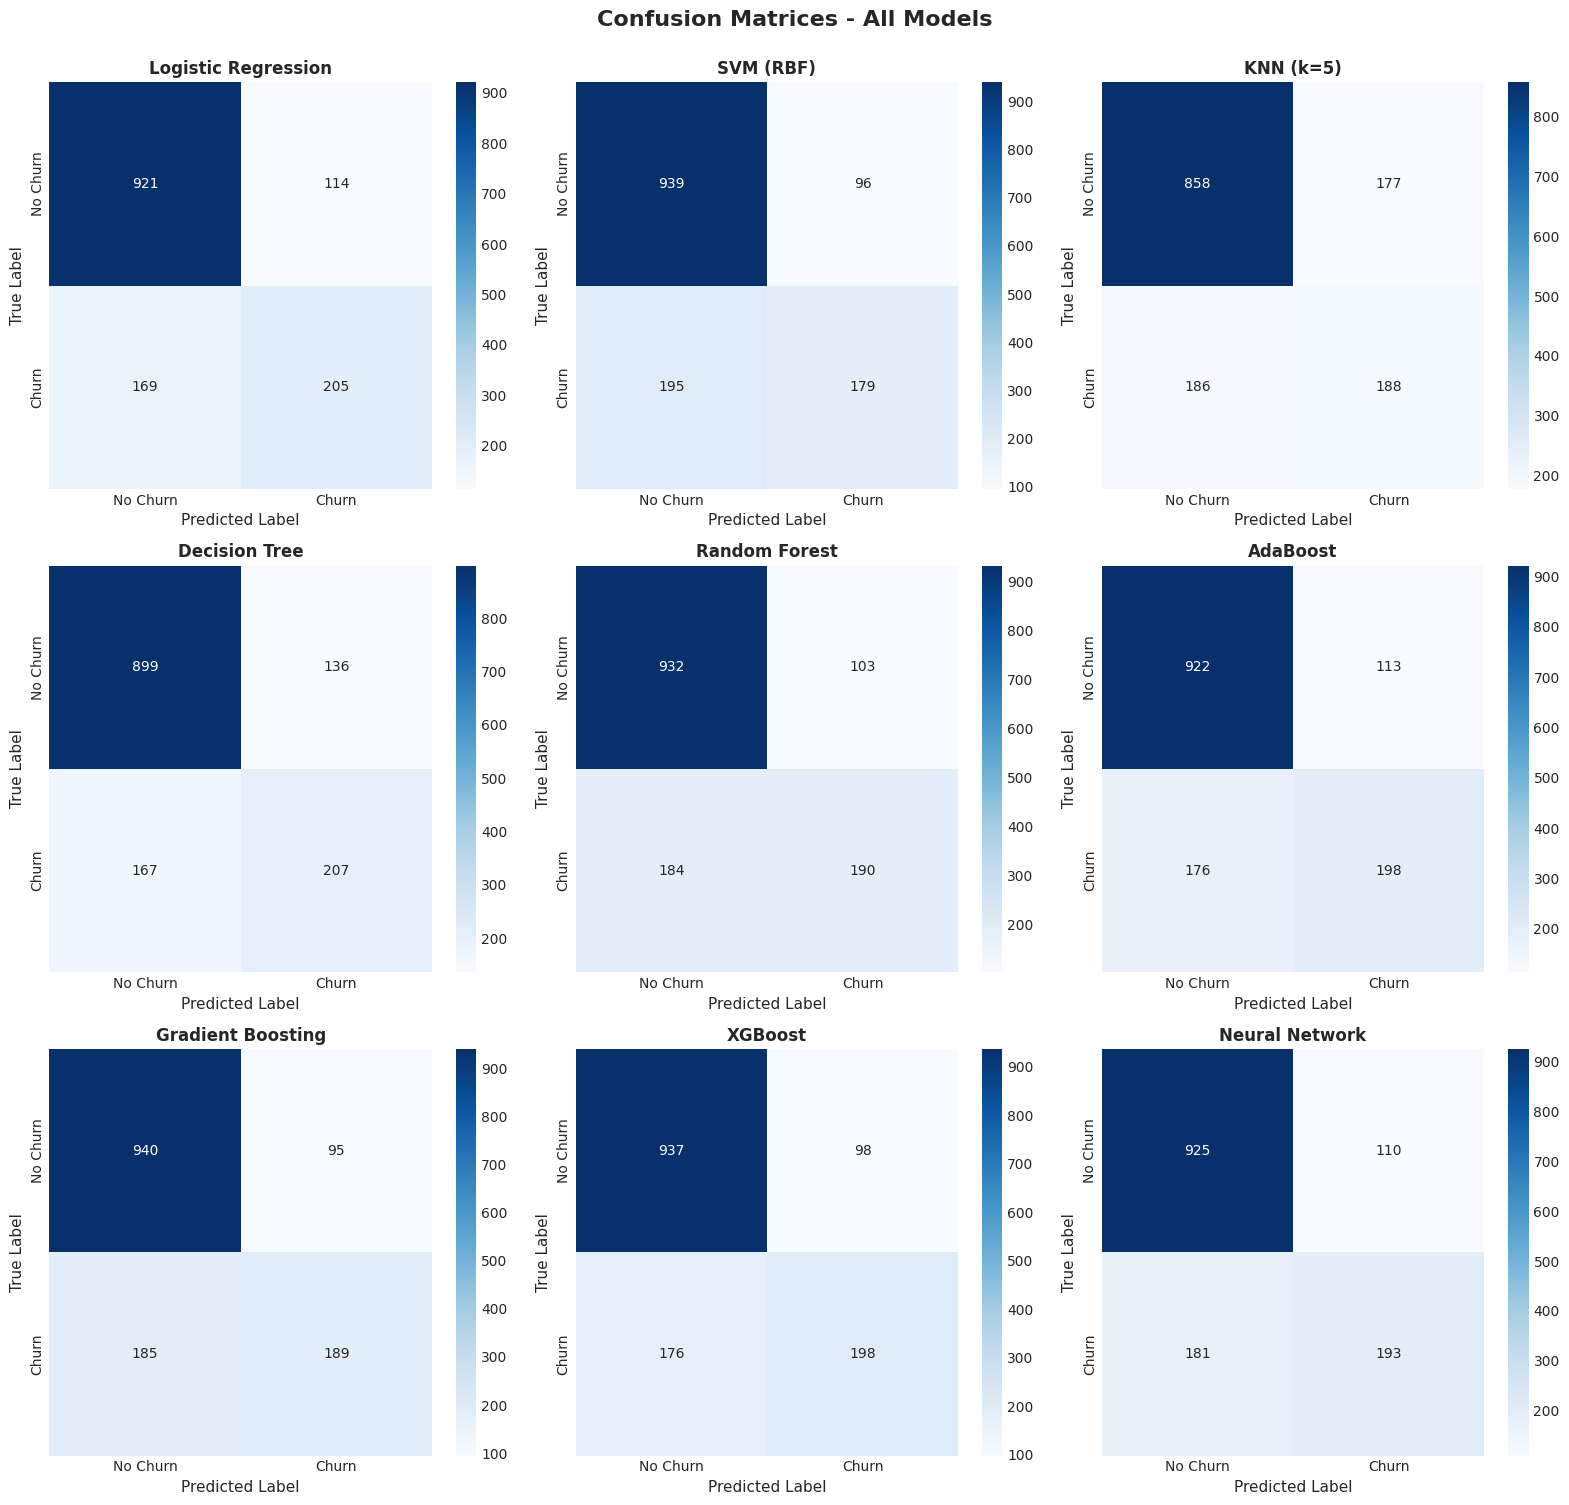

In [0]:
n_models = len(all_predictions)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, (model_name, (y_true, y_pred)) in enumerate(all_predictions.items()):
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['No Churn', 'Churn'],
               yticklabels=['No Churn', 'Churn'],
               ax=axes[idx], cbar=True)
    
    axes[idx].set_title(model_name, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 18.4 Feature Importance (for tree-based models)

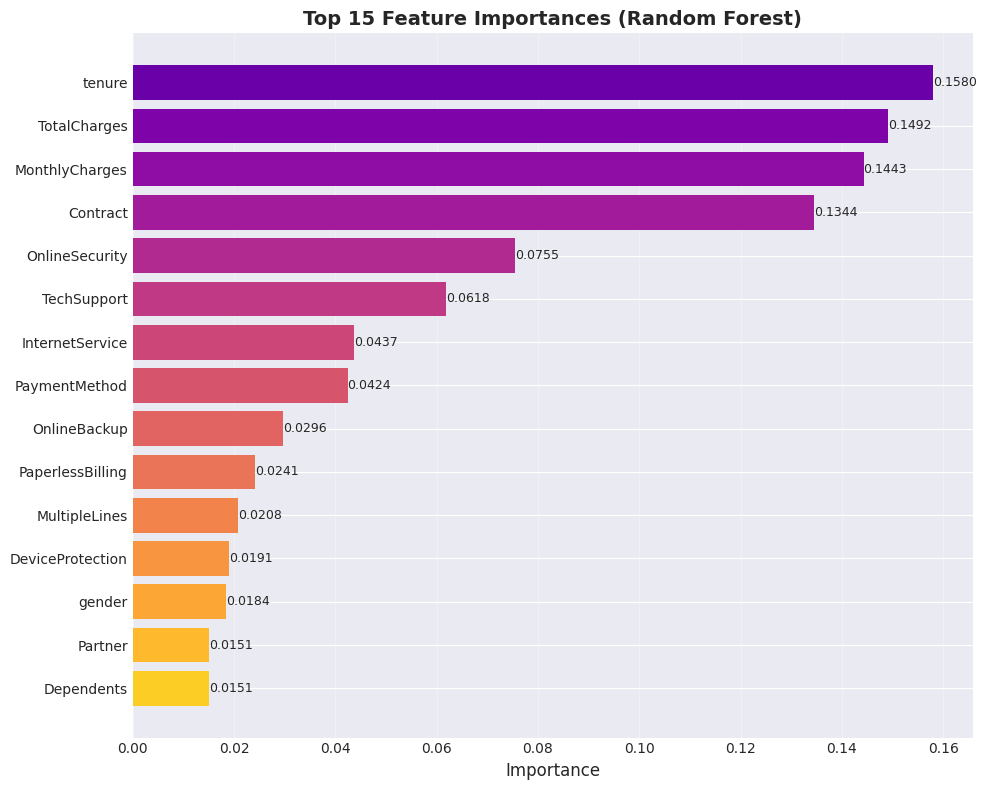

In [0]:
# Plot feature importance for Random Forest
try:
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]  # Top 15 features
    
    fig, ax = plt.subplots(figsize=(10, 8))
    colors_gradient = plt.cm.plasma(np.linspace(0.2, 0.9, len(indices)))
    
    feature_names_list = X.columns.tolist()
    top_features = [feature_names_list[i] for i in indices]
    top_importances = importances[indices]
    
    bars = ax.barh(top_features, top_importances, color=colors_gradient)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2,
               f'{width:.4f}', ha='left', va='center', fontsize=9)
    
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
except:
    print("Feature importance plot skipped (Random Forest not trained)")

## 19. Export Results

In [0]:
# Save comparison table to CSV
output_path = "/Workspace/Users/fatimaezzahraaboutaleb5@gmail.com/telco-churn-ml-databricks/comparison.csv"
df_comparison.to_csv(output_path, index=False)
print(f"✓ Results exported to: {output_path}")

# Log to MLflow
mlflow.log_artifact(output_path)

✓ Results exported to: /Workspace/Users/fatimaezzahraaboutaleb5@gmail.com/telco-churn-ml-databricks/comparison.csv




**Author:** Fatima-Ezzahra ABOUTALEB  
**Course:** Machine Learning  
**Date:** January 2026